<a href="https://colab.research.google.com/github/HariSharma10/Machine_Leaning/blob/main/Heart_disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['target'].value_counts())  # 1 = disease, 0 = no disease

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

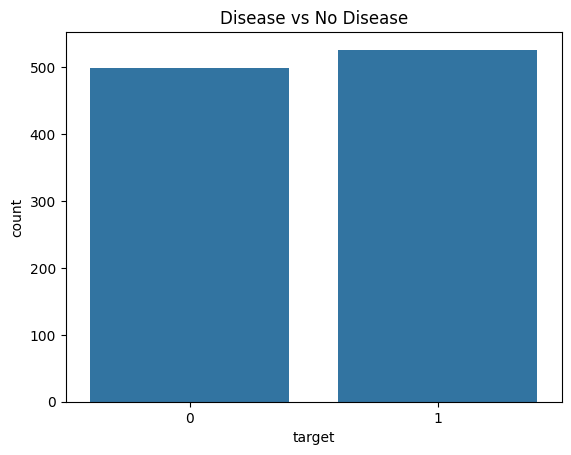

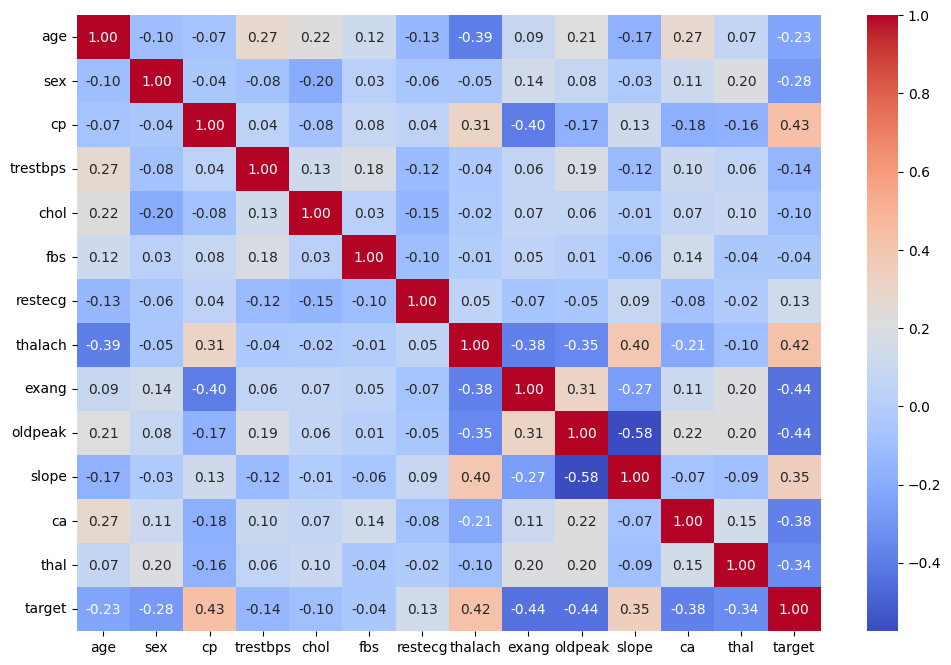

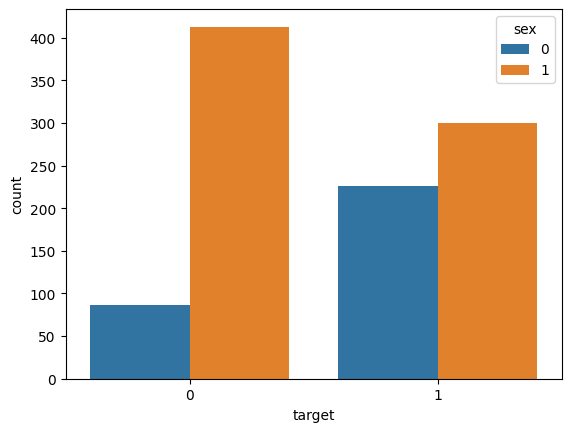

In [2]:
sns.countplot(data=df, x='target')
plt.title('Disease vs No Disease')
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

sns.countplot(data=df, x='target', hue='sex')
plt.show()

In [3]:
X = df.drop('target', axis=1)
y = df['target']

# All features here are numeric — no categorical text columns in this dataset
print(X.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



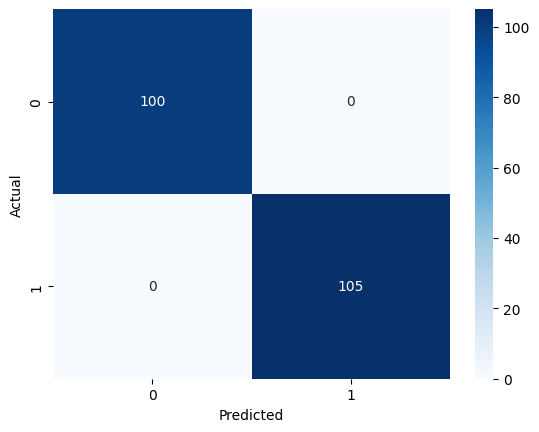

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cp          0.144796
thalach     0.118097
ca          0.110965
oldpeak     0.105590
thal        0.101825
age         0.091826
chol        0.076579
exang       0.074189
trestbps    0.071178
slope       0.045234
sex         0.029885
restecg     0.019166
fbs         0.010670
dtype: float64


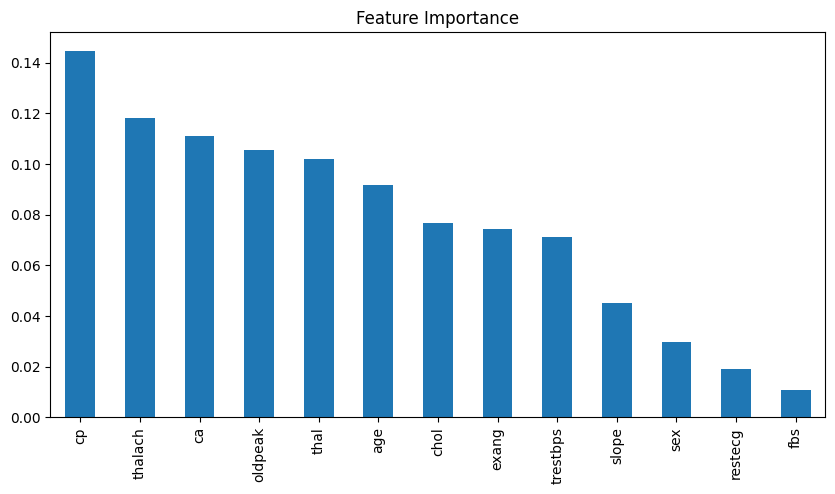

In [7]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feat_imp)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title('Feature Importance')
plt.show()

In [9]:
new_patient = pd.DataFrame([{
      'age': 55, 'sex': 1, 'cp': 0, 'trestbps': 140, 'chol': 250,
          'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0,
              'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
              }])

new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)

result = "Has heart disease" if prediction[0] == 1 else "No heart disease"
print(f"Prediction: {result}")
print(f"Confidence: {probability[0][prediction[0]]*100:.2f}%")


Prediction: Has heart disease
Confidence: 72.50%
